<a href="https://colab.research.google.com/github/josedanielisidororeyes/Natural_Language_Processing/blob/main/Clasificacion_de_Texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nombre: Jose Daniel Isidoro Reyes
# Tarea: Agrupación de Texto
# Materia: Procesamiento de Lenguaje Natura
# Fecha: 1 de mayo de 2026.

In [50]:
# Carga de librerías
!pip install gensim
from gensim.models import Word2Vec
import string
import nltk
import numpy as np
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
from collections import Counter

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Carga del Conjunto de Datos

In [16]:
dataset = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
docs_raw = dataset.data

# Preprocesamiento de Texto

In [17]:
def procesar_texto(text):
    # Normalizacíon: minúsculas y eliminación de signos de puntación
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenización
    tokens = word_tokenize(text)

    # Eliminación de stopwords
    sw = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in sw and len(t) > 2]

    return tokens

documentos_procesados  =  [procesar_texto(doc) for doc in docs_raw if len(doc.strip()) > 0]

Se realiza procesamiento del texto el cual incluye conversión a minusculas, signos de puntuacionm tokenización y eliminación de stopwords.

In [22]:
model_w2v =  Word2Vec(sentences  =  documentos_procesados, vector_size  =  100, window = 5, min_count =  2, workers =  4)

def get_doc_vector(tokens, model):
    # Creación del vector promedio del documento
    vectors  =  [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis  = 0)

X =  np.array([get_doc_vector(doc, model_w2v) for doc in documentos_procesados])

Se crean las representaciones vectoriales de tamaño 100 con la finalidad de capturar relaciones semanticas en el texto.

# K-Means

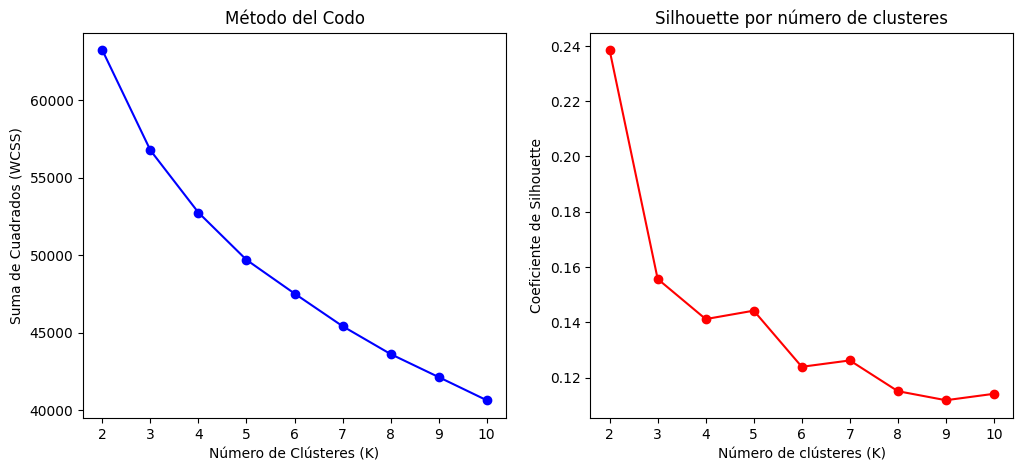

In [24]:
wcss = []
sil_scores =  []
K_range  =  range(2, 11)

for k in K_range:
    kmeans =  KMeans(n_clusters =  k, random_state =  42, n_init  =  10)
    labels =  kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Gráfico de Codo
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss,  'bo-')
plt.xlabel("Número de Clústeres (K)")
plt.ylabel('Suma de Cuadrados (WCSS)')
plt.title('Método del Codo')

# Gráfica del coeficiente de Silhouette
plt.subplot(1,2 , 2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel('Número de clústeres (K)')
plt.ylabel("Coeficiente de Silhouette")
plt.title('Silhouette por número de clusteres')
plt.show()


A través del analisis de suma de cuadrados internos al cluster es dificil elegir el número optimo de cluster al no haber un patrón claro de codo. Sin embargo, el coeficiente de silhouette sugiere que el número optimo de clusters es 5.

In [25]:
kmeans_final =  KMeans(n_clusters =  5, random_state = 42)
kmeans_labels = kmeans_final.fit_predict(X)

# Reporte de métricas
km_sil =  silhouette_score(X, kmeans_labels)
km_db =  davies_bouldin_score(X, kmeans_labels)
km_ch =  calinski_harabasz_score(X, kmeans_labels)

print(f"Métricas K-Means (K = {5}):")
print(f"Silhouette: {km_sil:.3f} (Cerca de 1 mejor)")
print(f"Davies-Bouilding: {km_db:.3f} (Cerca de 0 mejor)")
print(f"Calisnki-Harabasz: {km_ch:.3f} (Entre más alto mejor)")

Métricas K-Means (K = 5):
Silhouette: 0.144 (Cerca de 1 mejor)
Davies-Bouilding: 1.942 (Cerca de 0 mejor)
Calisnki-Harabasz: 2946.796 (Entre más alto mejor)


 El silhouette score sugiere una coección moderada, el davies-bouilden score es mayor a 1 y Podría sugerir que los grupos no están perfectamente separados. Finalmente la metricas Calinski-Harabasz sugiere que la estructura propuesta (5 clusteres es valida frente a una distribución aleatoria)

# DBSCAN Clustering

In [26]:
dbscan  =  DBSCAN(eps =  0.5, min_samples  =  5)
dbscan_labels =  dbscan.fit_predict(X)

# Filtro de ruido
mask =  dbscan_labels != 1
if len(np.unique(dbscan_labels[mask])) > 1:
    db_sil =  silhouette_score(X[mask], dbscan_labels[mask])
    db_dbi =  davies_bouldin_score(X[mask], dbscan_labels[mask])
    db_ch =  calinski_harabasz_score(X[mask], dbscan_labels[mask])

else:
    db_sil, db_dbi, db_ch  =  0, 0, 0

print("Metricas DBSCAN")
print(f"Silhouette: {db_sil:.3f}, DBI: {db_dbi:.3f}, CH: {db_ch:3}")

Metricas DBSCAN
Silhouette: -0.446, DBI: 1.466, CH: 22.080962932773566


El valor negativo del silhouette score sugiere que el algoritmo ha tenido difultades para encontrar densidades claras en los embeddings y el resto de indicadores son inferiores a los obtenidos en K-Means. Dado que DBSCAN es sensible a la selección de parametros, se requiere un análisis con más profundidad seleccionando diferentes combinaciones de parametros.

# Evaluación de métodos de clustering

In [29]:
comparativa = {
    "Métrica": ["Silhouette", "Davies-Bouldin (DBI)", "Calinski-Harabasz (CH)"],
    "K-Means": [km_sil, km_db, km_ch],
    "DBSCAN": [db_sil, db_dbi, db_ch]
}
df_comp = pd.DataFrame(comparativa)
print(df_comp)

                  Métrica      K-Means     DBSCAN
0              Silhouette     0.144139  -0.445599
1    Davies-Bouldin (DBI)     1.942397   1.465566
2  Calinski-Harabasz (CH)  2946.795638  22.080963


los resultados sugieren que KMeans obtiene mejores resultados (silhouete más cercano a 1 y Calinski-Harabazs más alto en comparación con DBSCAn).

# Visualización de resultados

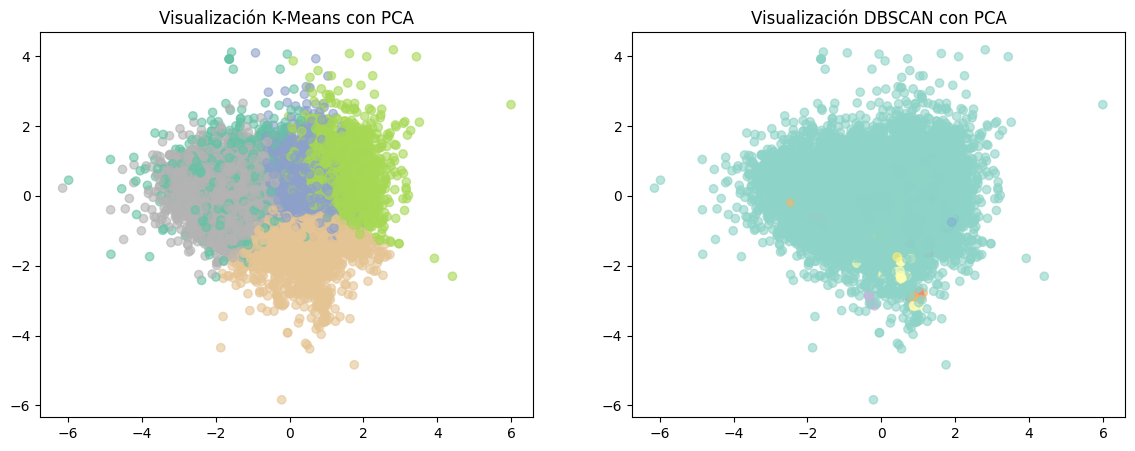

In [33]:
pca  =  PCA(n_components =  2, random_state =  42)
X_pca  =  pca.fit_transform(X)

plt.figure(figsize =  (14, 5))

# PCA K-Means
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_labels, cmap = "Set2", alpha  =  0.6)
plt.title("Visualización K-Means con PCA")

# PCA DBSCAN
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c =  dbscan_labels, cmap =  "Set3", alpha  =  0.6)
plt.title('Visualización DBSCAN con PCA')
plt.show()

Como se puede observa KMeans obtiene clusters decente, aunque aun se observa cierto solapamiento. En caso contrario, DBSCAN hace evidente que el algoritmo tuvo dificultad para encontrar densidades claras en los embeddings.

# Nube de palabras

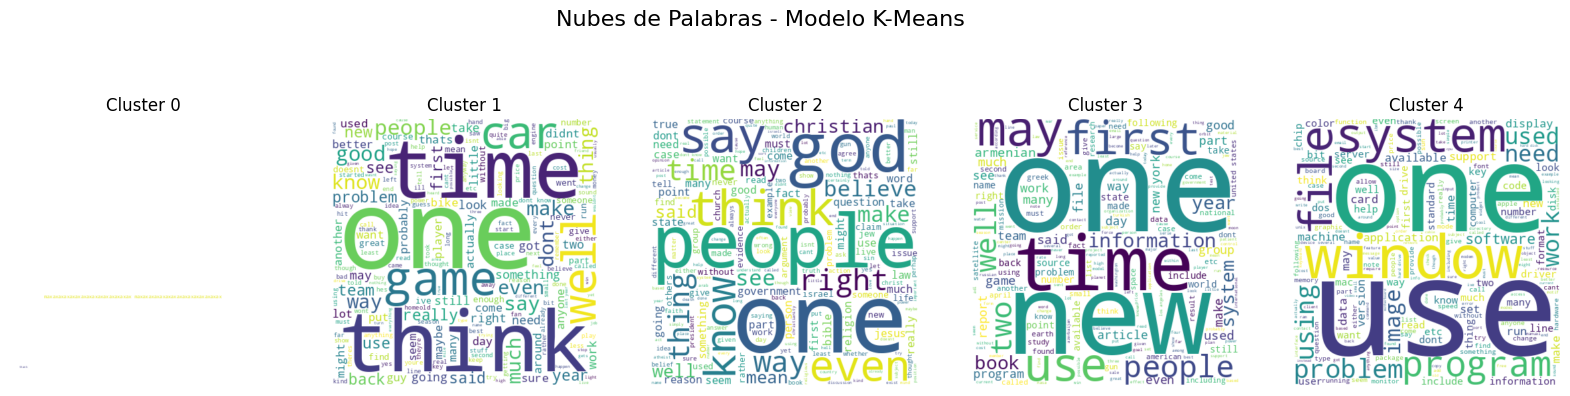

In [36]:
# Nube Kmeans
def generar_nube_por_cluster(labels, docs_procesados, titulo_modelo):
    n_clusters = len(np.unique(labels[labels != -1]))
    fig, axes = plt.subplots(1, n_clusters, figsize=(20, 5))
    fig.suptitle(f'Nubes de Palabras - {titulo_modelo}', fontsize=16)


    for i in range(n_clusters):
        texto_cluster = " ".join([" ".join(docs_procesados[j]) for j, l in enumerate(labels) if l == i])
        if not texto_cluster: continue
        wordcloud = WordCloud(width=400, height=400, background_color='white').generate(texto_cluster)
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f'Cluster {i}')
        axes[i].axis('off')
    plt.show()
generar_nube_por_cluster(kmeans_labels, documentos_procesados, "Modelo K-Means")


El analisis de nube de palabras revela que el cluster 0  está practicamente vacío lo cual podría deberse a ruido a datos atípicos. El segundo cluster sugiere temas de opinion, mientras que el cluster 2 sugiere religion. El cluster 3 puede  ser interpretado como actualizadad y el ultimo cluster como tecnología.

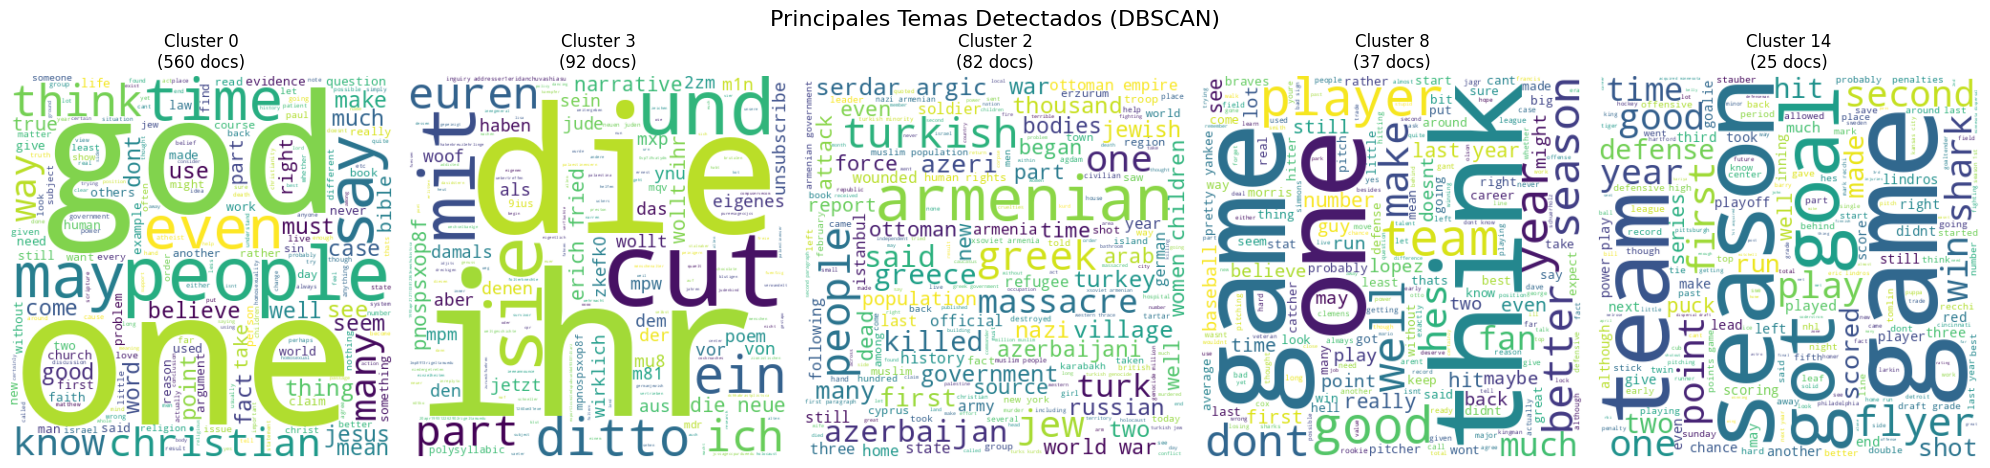

In [48]:
# Nube DBSCAN
counts = Counter(dbscan_labels)
if -1 in counts: del counts[-1]
top_clusters = [item[0] for item in counts.most_common(5)]

n_fotos = len(top_clusters)
if n_fotos > 0:
    fig, axes = plt.subplots(1, n_fotos, figsize=(4 * n_fotos, 5))
    fig.suptitle('Principales Temas Detectados (DBSCAN)', fontsize=16)

    if n_fotos == 1: axes = [axes]

    for i, label in enumerate(top_clusters):
        texto = " ".join([" ".join(documentos_procesados[j]) for j, l in enumerate(dbscan_labels) if l == label])
        wc = WordCloud(width=400, height=400, background_color='white').generate(texto)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Cluster {label}\n({counts[label]} docs)')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron clústeres significativos.")


El cluster 0 puede ser interpretado como religion, el cluster 1 como aleman, el 2 como política o historia de medio oriente, el siguiente como deporte y finalmente el 4 como juegos o competencia.
